<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
College = pd.read_csv('data/College.csv')

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
College.shape

(777, 19)

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [4]:
# Your code here
College.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [5]:
College.dtypes

Unnamed: 0         str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [6]:
College.isnull().sum()

Unnamed: 0     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [7]:
# Replace ? with missing value
College['PhD'] = College['PhD'].replace('?', np.nan)

# Convert the column to numbers
College['PhD'] = pd.to_numeric(College['PhD'], errors='coerce')

# Convert percentage values to decimals
College['PhD'] = College['PhD'] / 100

In [8]:
College.head(20)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,0.70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,0.29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,0.53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,0.92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,0.76,72,11.9,2,10922,15
5,Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,NaN,73,9.4,11,9727,55
6,Albertus Magnus College,Yes,353,340,103,17,45,416,230,13290,5720,500,1500,0.90,93,11.5,26,8861,63
7,Albion College,Yes,1899,1720,489,37,68,1594,32,13868,4826,450,850,0.89,100,13.7,37,11487,73
8,Albright College,Yes,1038,839,227,30,63,973,306,15595,4400,300,500,0.79,84,11.3,23,11644,80
9,Alderson-Broaddus College,Yes,582,498,172,21,44,799,78,10468,3380,660,1800,0.40,41,11.5,15,8991,52


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [9]:
# Your code here
# Convert the column to numbers
College['Grad.Rate'] = pd.to_numeric(College['Grad.Rate'], errors='coerce')

# Convert percentage values to decimals
College['Grad.Rate'] = College['Grad.Rate'] / 100

In [10]:
College.head(20)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,0.70,78,18.1,12,7041,0.60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,0.29,30,12.2,16,10527,0.56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,0.53,66,12.9,30,8735,0.54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,0.92,97,7.7,37,19016,0.59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,0.76,72,11.9,2,10922,0.15
5,Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,NaN,73,9.4,11,9727,0.55
6,Albertus Magnus College,Yes,353,340,103,17,45,416,230,13290,5720,500,1500,0.90,93,11.5,26,8861,0.63
7,Albion College,Yes,1899,1720,489,37,68,1594,32,13868,4826,450,850,0.89,100,13.7,37,11487,0.73
8,Albright College,Yes,1038,839,227,30,63,973,306,15595,4400,300,500,0.79,84,11.3,23,11644,0.80
9,Alderson-Broaddus College,Yes,582,498,172,21,44,799,78,10468,3380,660,1800,0.40,41,11.5,15,8991,0.52


In [11]:
College.dtypes

Unnamed: 0         str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD            float64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate      float64
dtype: object

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [12]:
%%writefile myutils.py
import numpy as np
import pandas as pd



def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 
    results = []

    # Select numeric columns only
    numeric_columns = df.select_dtypes(include=np.number).columns

    for column in numeric_columns:

        clean_column = df[column].dropna()
        unique_count = clean_column.nunique()

        # Skip empty or constant columns
        if unique_count <= 1:
            continue

        # Skip binary columns
        if unique_count == 2:
            continue

        # Skip common ID/index columns
        column_lower = column.lower()

        if (
            column_lower == "id"
            or column_lower.endswith("_id")
            or column_lower.startswith("id_")
        ):
            continue

        # Calculate skewness
        skewness = clean_column.skew()
        absolute_skewness = abs(skewness)
        minimum_value = clean_column.min()

        # Determine direction
        if skewness > 0:
            direction = "Right"
        elif skewness < 0:
            direction = "Left"
        else:
            direction = "Symmetric"

        # Determine degree and recommended transformation
        if absolute_skewness < 0.5:
            degree = "Approximately symmetric"
            transformation = "None"

        elif absolute_skewness < 1:
            degree = "Moderately skewed"

            #
            if skewness > 0 and minimum_value >= 0:
                transformation = "Square root"
            elif skewness < 0 and minimum_value >= 0:
                transformation = "Square"
            #if min<0 we should use Yeo
            else:
                transformation = "Yeo-Johnson"

        
        else:
            degree = "Highly skewed"

            #if there is not negative values do: 
            if skewness > 0 and minimum_value >= 0:
                transformation = "Try Log1p first; if skewness remains high, try Box-Cox"
            #if there is negative values do yeo:
            else:
                transformation = "Yeo-Johnson"

        #
        results.append({
            "Feature": column,
            "Skewness": skewness,
            "Degree": degree,
            "Direction": direction,
            "Recommended Transformation": transformation
        })

    skew_table = pd.DataFrame(results)

    if not skew_table.empty:
        skew_table["Skewness"] = skew_table["Skewness"].round(3)

    return skew_table


Overwriting myutils.py


In [13]:
# Now import the function from myutils
import myutils
results = myutils.skew_calc(College)
results


,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.724,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
1,Accept,3.418,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
2,Enroll,2.690,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
3,Top10perc,1.413,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
4,Top25perc,0.259,Approximately symmetric,Right,None
5,F.Undergrad,2.610,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
6,P.Undergrad,5.692,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
7,Outstate,0.509,Moderately skewed,Right,Square root
8,Room.Board,0.477,Approximately symmetric,Right,None
9,Books,3.485,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer


def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column and plots
    the original and transformed distributions side by side.

    Returns a transformed copy of the DataFrame.
    """

    transformed_df = pd.DataFrame()

    # Go through every row in the skewness table
    for index, row in skew_table.iterrows():

        feature = row["Feature"]
        transformation = row["Recommended Transformation"]
        valid_mask = df[feature].notna()
        original = df.loc[valid_mask, feature].astype(float)
        
        # Apply the recommended transformation
        if transformation == "None":
            transformed = original.copy()

        elif transformation == "Square root":
            transformed = np.sqrt(original)

        elif transformation == "Square":
            transformed = np.square(original)

        elif transformation == "Log1p":
            transformed = np.log1p(original)
        
        elif transformation == "Yeo-Johnson":
            pt = PowerTransformer(
                method="yeo-johnson", #choose the method
                standardize=False #Don't use standarlize 
            )
            # do the calculations 
            transformed_values = pt.fit_transform(
                #to_numpy(): Convert our data to NumPy array
                #reshape(-1,1): -1,1 make the NumPy array in two dimenionas to make it readable by PowerTransformation
                original.to_numpy().reshape(-1, 1) 
            ).flatten() # Recovert to NumPy array to make it easier to store in a pandas Series

            transformed = pd.Series(
                transformed_values,
                index=original.index
            )

            transformation = "Box-Cox"

        
        elif transformation == "Try Log1p first; if skewness remains high, try Box-Cox":

            # Try Log1p first
            log_transformed = np.log1p(original)
            log_skewness = log_transformed.skew()

            # If Log1p is still highly skewed, try Box-Cox
            if abs(log_skewness) > 0.5:

                # Box-Cox requires values greater than zero
                boxcox_original = original + 1

                pt = PowerTransformer(
                method="box-cox", #choose the method
                standardize=False #Don't use standarlize 
                )
                
                # do the calculations 
                transformed_values = pt.fit_transform(
                    #to_numpy(): Convert our data to NumPy array
                    #reshape(-1,1): -1,1 make the NumPy array in two dimenionas to make it readable by PowerTransformation
                    boxcox_original.to_numpy().reshape(-1, 1) 
                ).flatten() # Recovert to NumPy array to make it easier to store in a pandas Series

                transformed = pd.Series(
                    transformed_values,
                    index=original.index
                )

                transformation = "Box-Cox"

            else:
                transformed = log_transformed
                transformation = "Log1p"


        
        else:
            transformed = original.copy()

        # Store the transformed values
        transformed_df[feature+' transform'] = transformed

        # Calculate skewness before and after
        before_skew = original.skew()
        after_skew = transformed.skew()

        # Plot both distributions
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(original, kde=True, ax=axes[0])
        axes[0].set_title(
            f"{feature} — Before\nSkewness = {before_skew:.3f}"
        )
        axes[0].set_xlabel(feature)

        sns.histplot(transformed, kde=True, ax=axes[1])
        axes[1].set_title(
            f"{feature} — After {transformation}\n"
            f"Skewness = {after_skew:.3f}"
        )
        axes[1].set_xlabel(feature)

        plt.tight_layout()
        plt.show()

    return transformed_df

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [15]:
# Your code here
import myutils
skew_table = myutils.skew_calc(College)
skew_table


,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.724,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
1,Accept,3.418,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
2,Enroll,2.690,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
3,Top10perc,1.413,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
4,Top25perc,0.259,Approximately symmetric,Right,None
5,F.Undergrad,2.610,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
6,P.Undergrad,5.692,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."
7,Outstate,0.509,Moderately skewed,Right,Square root
8,Room.Board,0.477,Approximately symmetric,Right,None
9,Books,3.485,Highly skewed,Right,"Try Log1p first; if skewness remains high, try..."


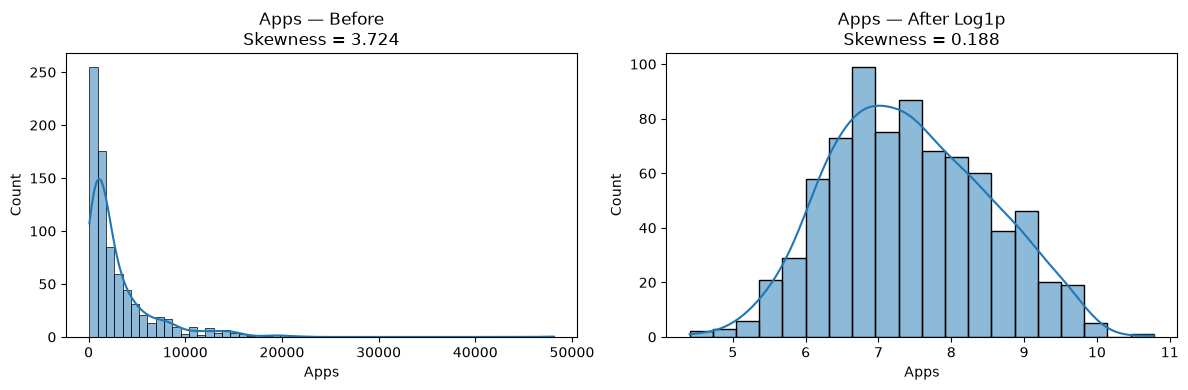

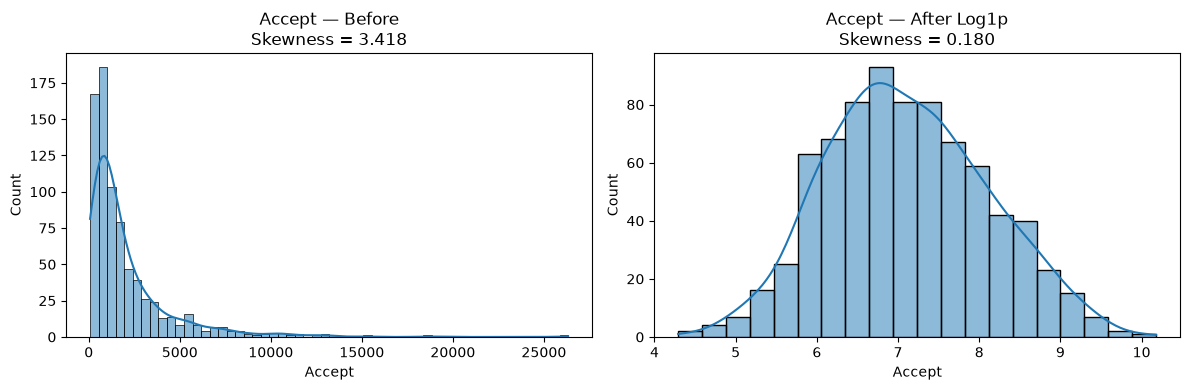

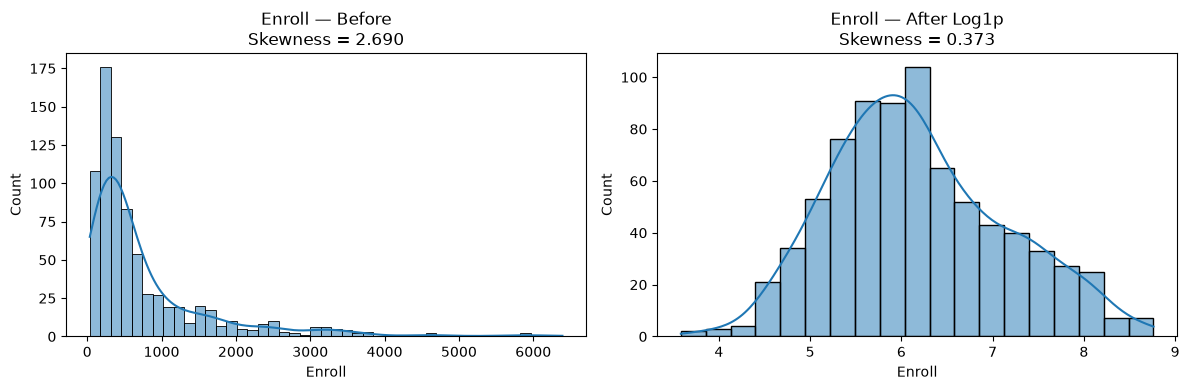

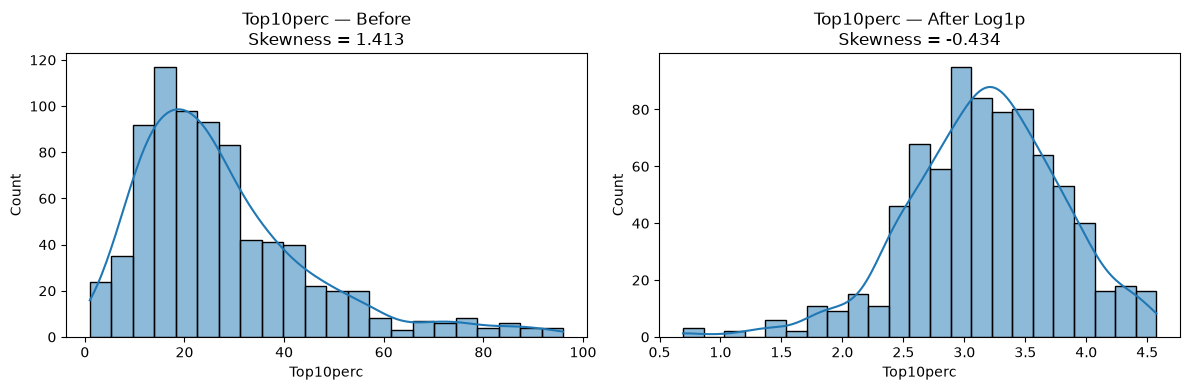

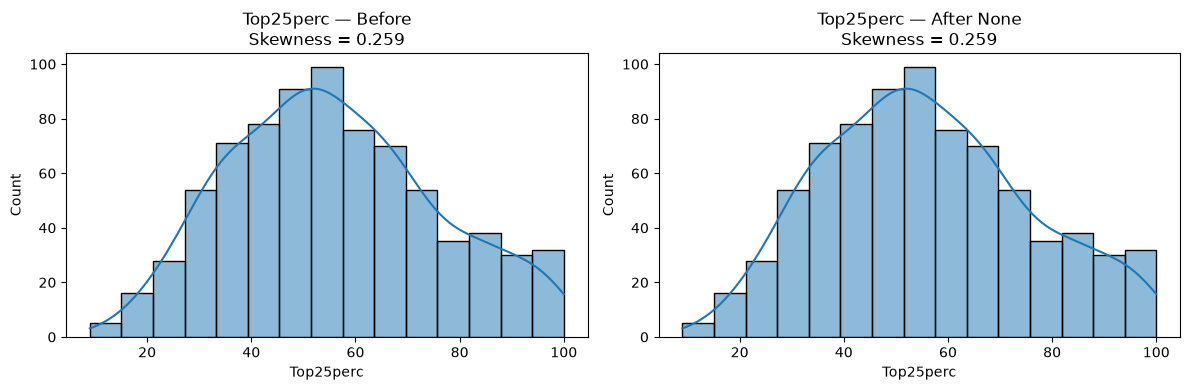

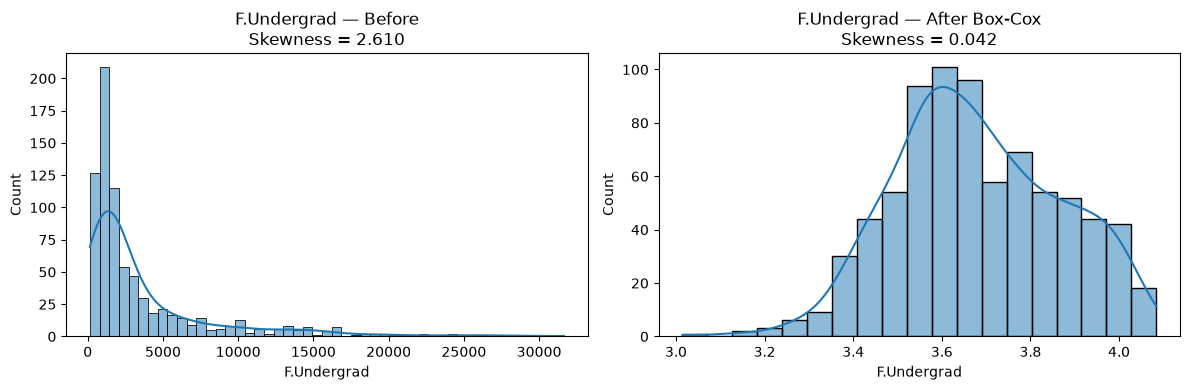

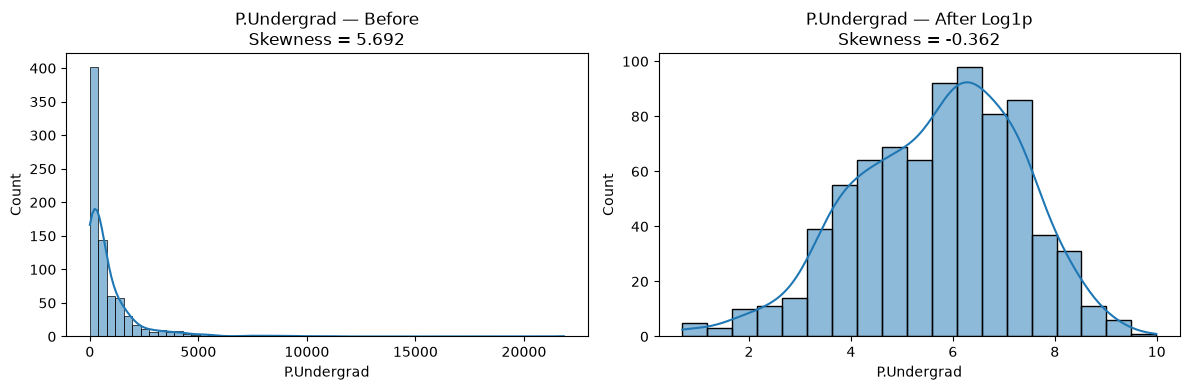

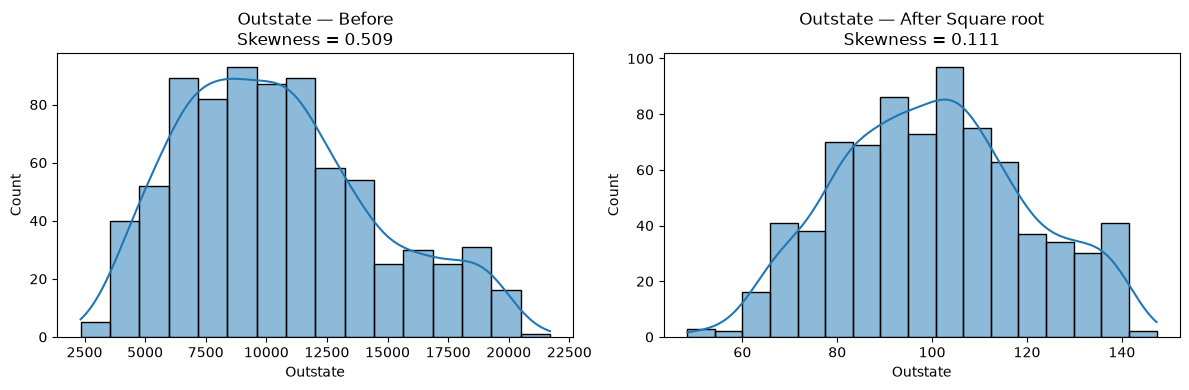

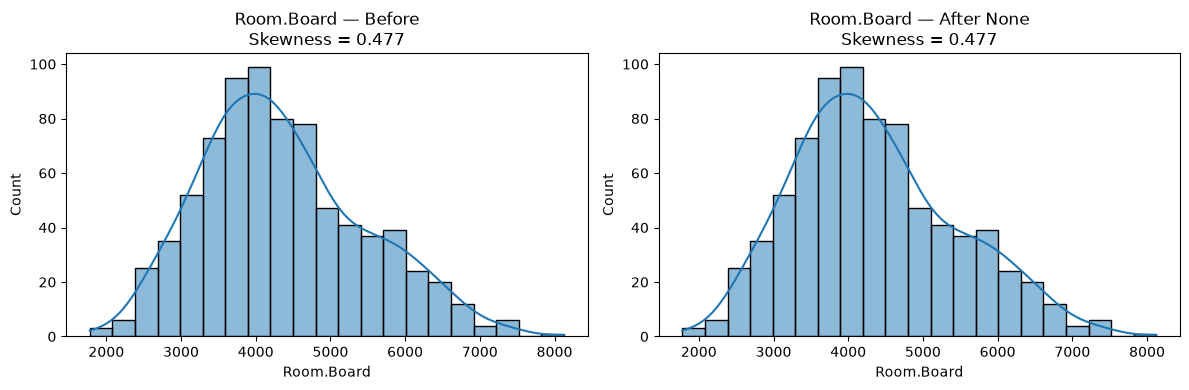

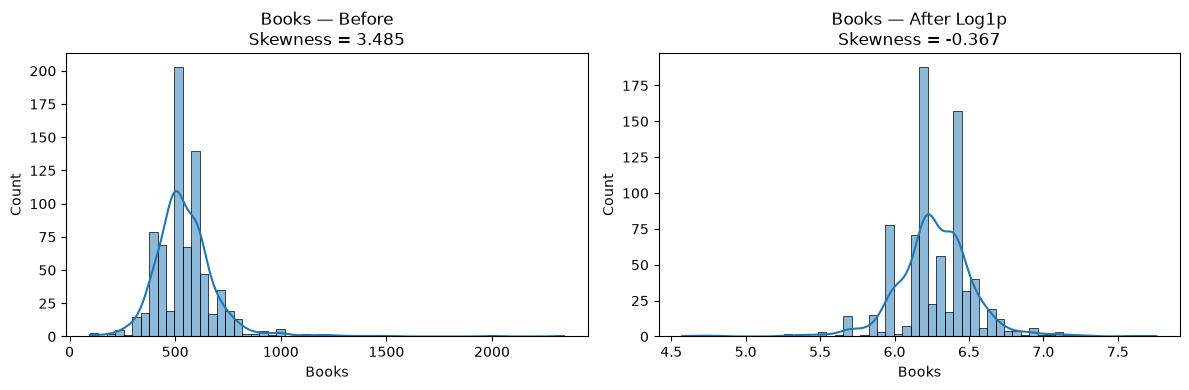

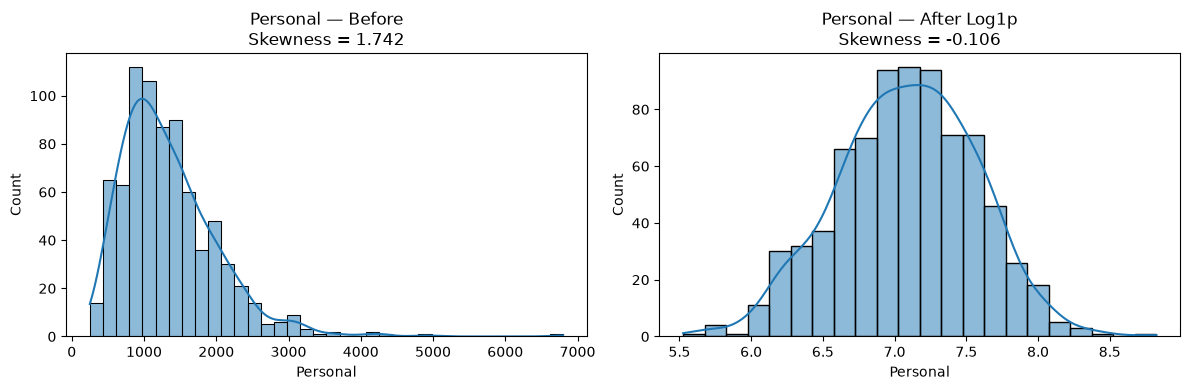

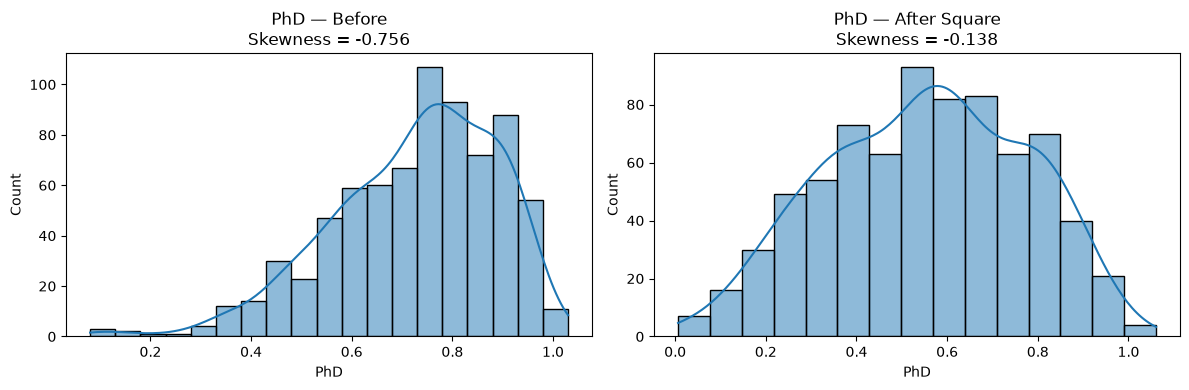

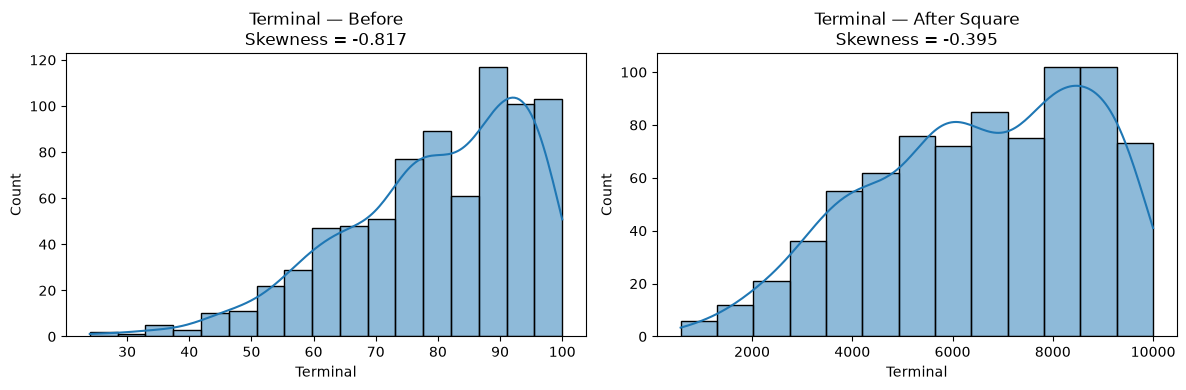

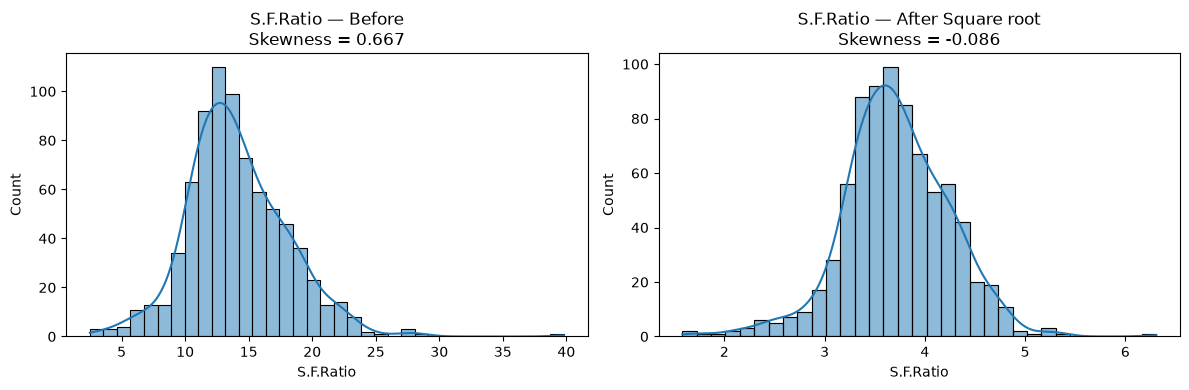

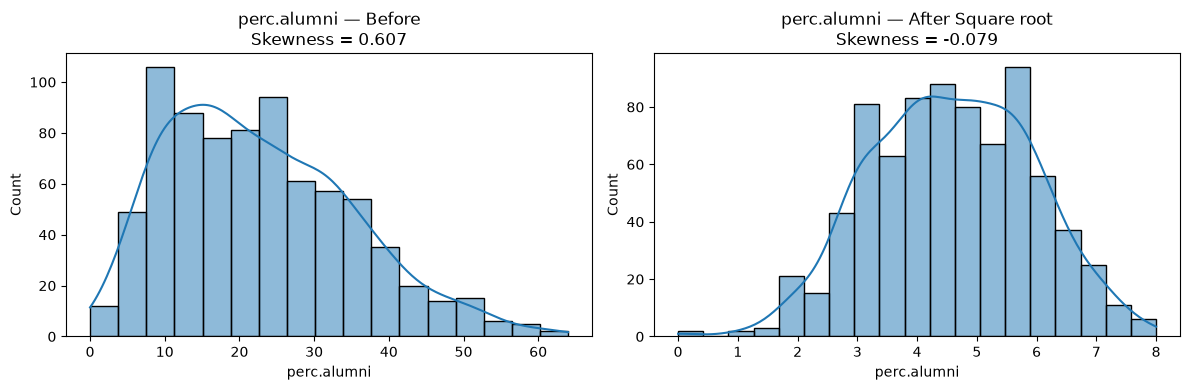

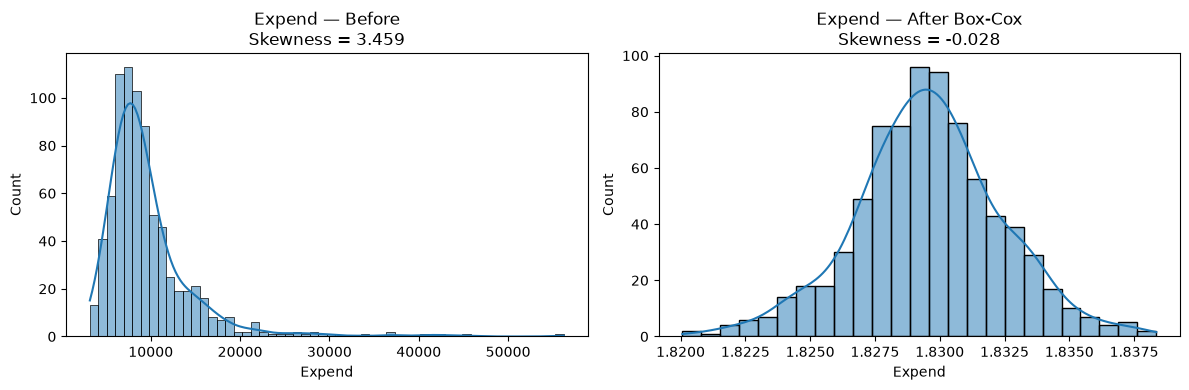

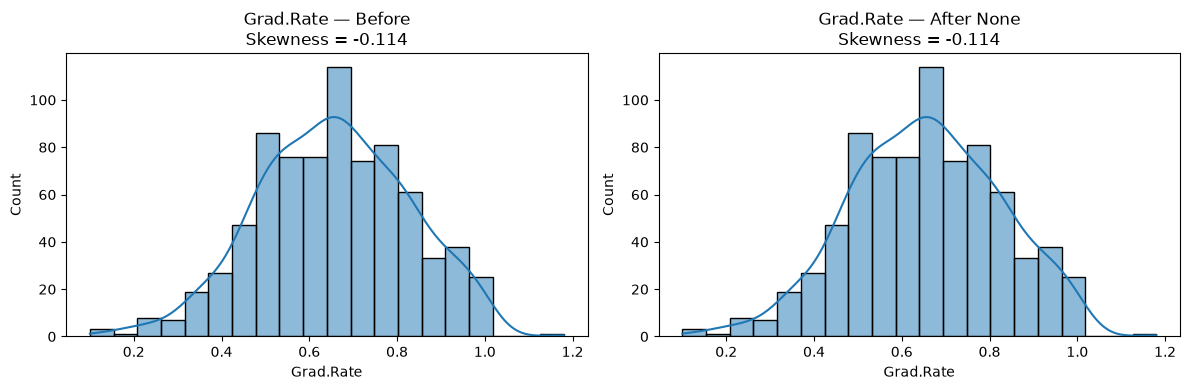

In [16]:
# Your code here
Collage_Transform = plot_transformations(College, skew_table)

In [17]:
Collage_Transform.columns

Index(['Apps transform', 'Accept transform', 'Enroll transform',
       'Top10perc transform', 'Top25perc transform', 'F.Undergrad transform',
       'P.Undergrad transform', 'Outstate transform', 'Room.Board transform',
       'Books transform', 'Personal transform', 'PhD transform',
       'Terminal transform', 'S.F.Ratio transform', 'perc.alumni transform',
       'Expend transform', 'Grad.Rate transform'],
      dtype='str')

In [18]:
College.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='str')

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [19]:
trans_cols = ['Apps transform', 'Accept transform', 'Enroll transform',
       'Top10perc transform', 'Top25perc transform', 'F.Undergrad transform',
       'P.Undergrad transform', 'Outstate transform', 'Room.Board transform',
       'Books transform', 'Personal transform', 'PhD transform',
       'Terminal transform', 'S.F.Ratio transform', 'perc.alumni transform',
       'Expend transform', 'Grad.Rate transform']

categorical_cols = ['Unnamed: 0', 'Private']
Collage_final = pd.concat(
    [
        College[categorical_cols],
        Collage_Transform[trans_cols]
    ],
    axis=1
)


# Your code here 
# Already Created in the funtion 
Collage_final 

,Unnamed: 0,Private,Apps transform,Accept transform,Enroll transform,Top10perc transform,Top25perc transform,F.Undergrad transform,P.Undergrad transform,Outstate transform,Room.Board transform,Books transform,Personal transform,PhD transform,Terminal transform,S.F.Ratio transform,perc.alumni transform,Expend transform,Grad.Rate transform
0,Abilene Christian University,Yes,7.415175,7.117206,6.582025,3.178054,52.0,3.760783,6.287859,86.255435,3300.0,6.111467,7.696667,0.4900,6084.0,4.254409,3.464102,1.828168,0.60
1,Adelphi University,Yes,7.690286,7.562681,6.240276,2.833213,29.0,3.748082,7.113142,110.815161,6450.0,6.621406,7.313887,0.0841,900.0,3.492850,4.000000,1.831122,0.56
2,Adrian College,Yes,7.264730,7.001246,5.820083,3.135494,50.0,3.561472,4.605170,106.066017,3750.0,5.993961,7.061334,0.2809,4356.0,3.591657,5.477226,1.829832,0.54
3,Agnes Scott College,Yes,6.035481,5.857933,4.927254,4.110874,89.0,3.394972,4.158883,113.841996,5450.0,6.111467,6.775366,0.8464,9409.0,2.774887,6.082763,1.834447,0.59
4,Alaska Pacific University,Yes,5.267858,4.990433,4.025352,2.833213,44.0,3.198323,6.768493,86.948260,4120.0,6.685861,7.313887,0.5776,5184.0,3.449638,1.414214,1.831362,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,7.695303,7.323831,6.298949,1.609438,26.0,3.772555,7.615791,82.443920,3900.0,6.216606,7.090910,0.3600,3600.0,4.582576,3.741657,1.823954,0.40
773,Xavier University,Yes,7.580700,7.498870,6.545350,3.218876,47.0,3.758600,7.010312,107.331263,4960.0,6.398595,7.131699,0.5329,5625.0,3.646917,5.567764,1.830195,0.83
774,Xavier University of Louisiana,Yes,7.648740,7.557995,6.545350,3.555348,61.0,3.755137,5.117994,83.066239,4200.0,6.426488,6.661855,0.4489,5625.0,3.794733,4.472136,1.829476,0.49
775,Yale University,Yes,9.278560,7.805475,7.183871,4.564348,99.0,3.857216,4.430817,140.854535,6510.0,6.447306,7.657283,0.9216,9216.0,2.408319,7.000000,1.837396,0.99


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [20]:
# Your code here 
#Accept formula because transfomr methods is a same 
Collage_final ['Accept_Rate'] = Collage_final['Accept transform'] /Collage_final['Apps transform']

In [21]:
Collage_final

,Unnamed: 0,Private,Apps transform,Accept transform,Enroll transform,Top10perc transform,Top25perc transform,F.Undergrad transform,P.Undergrad transform,Outstate transform,Room.Board transform,Books transform,Personal transform,PhD transform,Terminal transform,S.F.Ratio transform,perc.alumni transform,Expend transform,Grad.Rate transform,Accept_Rate
0,Abilene Christian University,Yes,7.415175,7.117206,6.582025,3.178054,52.0,3.760783,6.287859,86.255435,3300.0,6.111467,7.696667,0.4900,6084.0,4.254409,3.464102,1.828168,0.60,0.959816
1,Adelphi University,Yes,7.690286,7.562681,6.240276,2.833213,29.0,3.748082,7.113142,110.815161,6450.0,6.621406,7.313887,0.0841,900.0,3.492850,4.000000,1.831122,0.56,0.983407
2,Adrian College,Yes,7.264730,7.001246,5.820083,3.135494,50.0,3.561472,4.605170,106.066017,3750.0,5.993961,7.061334,0.2809,4356.0,3.591657,5.477226,1.829832,0.54,0.963731
3,Agnes Scott College,Yes,6.035481,5.857933,4.927254,4.110874,89.0,3.394972,4.158883,113.841996,5450.0,6.111467,6.775366,0.8464,9409.0,2.774887,6.082763,1.834447,0.59,0.970583
4,Alaska Pacific University,Yes,5.267858,4.990433,4.025352,2.833213,44.0,3.198323,6.768493,86.948260,4120.0,6.685861,7.313887,0.5776,5184.0,3.449638,1.414214,1.831362,0.15,0.947336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,7.695303,7.323831,6.298949,1.609438,26.0,3.772555,7.615791,82.443920,3900.0,6.216606,7.090910,0.3600,3600.0,4.582576,3.741657,1.823954,0.40,0.951727
773,Xavier University,Yes,7.580700,7.498870,6.545350,3.218876,47.0,3.758600,7.010312,107.331263,4960.0,6.398595,7.131699,0.5329,5625.0,3.646917,5.567764,1.830195,0.83,0.989205
774,Xavier University of Louisiana,Yes,7.648740,7.557995,6.545350,3.555348,61.0,3.755137,5.117994,83.066239,4200.0,6.426488,6.661855,0.4489,5625.0,3.794733,4.472136,1.829476,0.49,0.988136
775,Yale University,Yes,9.278560,7.805475,7.183871,4.564348,99.0,3.857216,4.430817,140.854535,6510.0,6.447306,7.657283,0.9216,9216.0,2.408319,7.000000,1.837396,0.99,0.841238


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [22]:
# Your code here 
Collage_final["Outstate_Tier"] = pd.cut(
    Collage_final["Outstate transform"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

Collage_final

,Unnamed: 0,Private,Apps transform,Accept transform,Enroll transform,Top10perc transform,Top25perc transform,F.Undergrad transform,P.Undergrad transform,Outstate transform,...,Books transform,Personal transform,PhD transform,Terminal transform,S.F.Ratio transform,perc.alumni transform,Expend transform,Grad.Rate transform,Accept_Rate,Outstate_Tier
0,Abilene Christian University,Yes,7.415175,7.117206,6.582025,3.178054,52.0,3.760783,6.287859,86.255435,...,6.111467,7.696667,0.4900,6084.0,4.254409,3.464102,1.828168,0.60,0.959816,Medium
1,Adelphi University,Yes,7.690286,7.562681,6.240276,2.833213,29.0,3.748082,7.113142,110.815161,...,6.621406,7.313887,0.0841,900.0,3.492850,4.000000,1.831122,0.56,0.983407,Medium
2,Adrian College,Yes,7.264730,7.001246,5.820083,3.135494,50.0,3.561472,4.605170,106.066017,...,5.993961,7.061334,0.2809,4356.0,3.591657,5.477226,1.829832,0.54,0.963731,Medium
3,Agnes Scott College,Yes,6.035481,5.857933,4.927254,4.110874,89.0,3.394972,4.158883,113.841996,...,6.111467,6.775366,0.8464,9409.0,2.774887,6.082763,1.834447,0.59,0.970583,Medium
4,Alaska Pacific University,Yes,5.267858,4.990433,4.025352,2.833213,44.0,3.198323,6.768493,86.948260,...,6.685861,7.313887,0.5776,5184.0,3.449638,1.414214,1.831362,0.15,0.947336,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,7.695303,7.323831,6.298949,1.609438,26.0,3.772555,7.615791,82.443920,...,6.216606,7.090910,0.3600,3600.0,4.582576,3.741657,1.823954,0.40,0.951727,Medium
773,Xavier University,Yes,7.580700,7.498870,6.545350,3.218876,47.0,3.758600,7.010312,107.331263,...,6.398595,7.131699,0.5329,5625.0,3.646917,5.567764,1.830195,0.83,0.989205,Medium
774,Xavier University of Louisiana,Yes,7.648740,7.557995,6.545350,3.555348,61.0,3.755137,5.117994,83.066239,...,6.426488,6.661855,0.4489,5625.0,3.794733,4.472136,1.829476,0.49,0.988136,Medium
775,Yale University,Yes,9.278560,7.805475,7.183871,4.564348,99.0,3.857216,4.430817,140.854535,...,6.447306,7.657283,0.9216,9216.0,2.408319,7.000000,1.837396,0.99,0.841238,High


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [23]:
# Your code here 

Collage_final["Outstate_Tier"] = (
    Collage_final["Outstate_Tier"]
    .map({
        "Low": 0,
        "Medium": 1,
        "High": 2
    })
)

Collage_final

,Unnamed: 0,Private,Apps transform,Accept transform,Enroll transform,Top10perc transform,Top25perc transform,F.Undergrad transform,P.Undergrad transform,Outstate transform,...,Books transform,Personal transform,PhD transform,Terminal transform,S.F.Ratio transform,perc.alumni transform,Expend transform,Grad.Rate transform,Accept_Rate,Outstate_Tier
0,Abilene Christian University,Yes,7.415175,7.117206,6.582025,3.178054,52.0,3.760783,6.287859,86.255435,...,6.111467,7.696667,0.4900,6084.0,4.254409,3.464102,1.828168,0.60,0.959816,1
1,Adelphi University,Yes,7.690286,7.562681,6.240276,2.833213,29.0,3.748082,7.113142,110.815161,...,6.621406,7.313887,0.0841,900.0,3.492850,4.000000,1.831122,0.56,0.983407,1
2,Adrian College,Yes,7.264730,7.001246,5.820083,3.135494,50.0,3.561472,4.605170,106.066017,...,5.993961,7.061334,0.2809,4356.0,3.591657,5.477226,1.829832,0.54,0.963731,1
3,Agnes Scott College,Yes,6.035481,5.857933,4.927254,4.110874,89.0,3.394972,4.158883,113.841996,...,6.111467,6.775366,0.8464,9409.0,2.774887,6.082763,1.834447,0.59,0.970583,1
4,Alaska Pacific University,Yes,5.267858,4.990433,4.025352,2.833213,44.0,3.198323,6.768493,86.948260,...,6.685861,7.313887,0.5776,5184.0,3.449638,1.414214,1.831362,0.15,0.947336,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,7.695303,7.323831,6.298949,1.609438,26.0,3.772555,7.615791,82.443920,...,6.216606,7.090910,0.3600,3600.0,4.582576,3.741657,1.823954,0.40,0.951727,1
773,Xavier University,Yes,7.580700,7.498870,6.545350,3.218876,47.0,3.758600,7.010312,107.331263,...,6.398595,7.131699,0.5329,5625.0,3.646917,5.567764,1.830195,0.83,0.989205,1
774,Xavier University of Louisiana,Yes,7.648740,7.557995,6.545350,3.555348,61.0,3.755137,5.117994,83.066239,...,6.426488,6.661855,0.4489,5625.0,3.794733,4.472136,1.829476,0.49,0.988136,1
775,Yale University,Yes,9.278560,7.805475,7.183871,4.564348,99.0,3.857216,4.430817,140.854535,...,6.447306,7.657283,0.9216,9216.0,2.408319,7.000000,1.837396,0.99,0.841238,2


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [24]:
# Your code here 
Collage_final["Private"] = (
    Collage_final["Private"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

In [25]:
Collage_final

,Unnamed: 0,Private,Apps transform,Accept transform,Enroll transform,Top10perc transform,Top25perc transform,F.Undergrad transform,P.Undergrad transform,Outstate transform,...,Books transform,Personal transform,PhD transform,Terminal transform,S.F.Ratio transform,perc.alumni transform,Expend transform,Grad.Rate transform,Accept_Rate,Outstate_Tier
0,Abilene Christian University,1,7.415175,7.117206,6.582025,3.178054,52.0,3.760783,6.287859,86.255435,...,6.111467,7.696667,0.4900,6084.0,4.254409,3.464102,1.828168,0.60,0.959816,1
1,Adelphi University,1,7.690286,7.562681,6.240276,2.833213,29.0,3.748082,7.113142,110.815161,...,6.621406,7.313887,0.0841,900.0,3.492850,4.000000,1.831122,0.56,0.983407,1
2,Adrian College,1,7.264730,7.001246,5.820083,3.135494,50.0,3.561472,4.605170,106.066017,...,5.993961,7.061334,0.2809,4356.0,3.591657,5.477226,1.829832,0.54,0.963731,1
3,Agnes Scott College,1,6.035481,5.857933,4.927254,4.110874,89.0,3.394972,4.158883,113.841996,...,6.111467,6.775366,0.8464,9409.0,2.774887,6.082763,1.834447,0.59,0.970583,1
4,Alaska Pacific University,1,5.267858,4.990433,4.025352,2.833213,44.0,3.198323,6.768493,86.948260,...,6.685861,7.313887,0.5776,5184.0,3.449638,1.414214,1.831362,0.15,0.947336,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,0,7.695303,7.323831,6.298949,1.609438,26.0,3.772555,7.615791,82.443920,...,6.216606,7.090910,0.3600,3600.0,4.582576,3.741657,1.823954,0.40,0.951727,1
773,Xavier University,1,7.580700,7.498870,6.545350,3.218876,47.0,3.758600,7.010312,107.331263,...,6.398595,7.131699,0.5329,5625.0,3.646917,5.567764,1.830195,0.83,0.989205,1
774,Xavier University of Louisiana,1,7.648740,7.557995,6.545350,3.555348,61.0,3.755137,5.117994,83.066239,...,6.426488,6.661855,0.4489,5625.0,3.794733,4.472136,1.829476,0.49,0.988136,1
775,Yale University,1,9.278560,7.805475,7.183871,4.564348,99.0,3.857216,4.430817,140.854535,...,6.447306,7.657283,0.9216,9216.0,2.408319,7.000000,1.837396,0.99,0.841238,2


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [26]:
# Your code here 
Scaled_College= pd.DataFrame()
scaler = StandardScaler()

cols_to_scale = [
    'Apps transform',
    'Accept transform',
    'Enroll transform',
    'Top10perc transform',
    'Top25perc transform',
    'F.Undergrad transform',
    'P.Undergrad transform',
    'Outstate transform',
    'Room.Board transform',
    'Books transform',
    'Personal transform',
    'PhD transform',
    'Terminal transform',
    'S.F.Ratio transform',
    'perc.alumni transform',
    'Expend transform',
]

Non_Scaled_Columns= [
    'Private',
    'Outstate_Tier',
    'Accept_Rate',
    'Grad.Rate transform'
]

scaled_values = scaler.fit_transform(
    Collage_final[cols_to_scale]
)

scaled_column_names = [
    col + "_scaled"
    for col in cols_to_scale
]

Scaled_College[scaled_column_names] = scaled_values

Scaled_College = pd.concat(
    [
        Collage_final[Non_Scaled_Columns],
        Scaled_College[scaled_column_names]
    ],
    axis=1
)


Scaled_College.head()

,Private,Outstate_Tier,Accept_Rate,Grad.Rate transform,Apps transform_scaled,Accept transform_scaled,Enroll transform_scaled,Top10perc transform_scaled,Top25perc transform_scaled,F.Undergrad transform_scaled,P.Undergrad transform_scaled,Outstate transform_scaled,Room.Board transform_scaled,Books transform_scaled,Personal transform_scaled,PhD transform_scaled,Terminal transform_scaled,S.F.Ratio transform_scaled,perc.alumni transform_scaled,Expend transform_scaled
0,1,1,0.959816,0.60,-0.011583,0.006320,0.427055,0.014037,-0.191827,0.433757,0.361674,-0.710846,-0.964905,-0.601556,1.259401,-0.284506,-0.221884,1.014538,-0.826646,-0.491190
1,1,1,0.983407,0.56,0.245031,0.457067,0.067493,-0.535636,-1.353911,0.365526,0.875509,0.535600,1.909208,1.286817,0.469963,-2.132810,-2.593581,-0.420242,-0.428082,0.552370
2,1,1,0.963731,0.54,-0.151913,-0.111012,-0.374601,-0.053802,-0.292878,-0.636916,-0.685997,0.294573,-0.554317,-1.036697,-0.050896,-1.236663,-1.012450,-0.234089,0.670575,0.096393
3,1,1,0.970583,0.59,-1.298516,-1.267855,-1.313967,1.500947,1.677612,-1.531331,-0.963863,0.689217,0.996791,-0.601556,-0.640670,1.338396,1.299314,-1.772885,1.120931,1.727003
4,1,1,0.947336,0.15,-2.014530,-2.145621,-2.262878,-0.535636,-0.596031,-2.587702,0.660925,-0.675684,-0.216723,1.525504,0.469963,0.114389,-0.633637,-0.501654,-2.351209,0.637052


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [27]:
Scaled_College.columns

Index(['Private', 'Outstate_Tier', 'Accept_Rate', 'Grad.Rate transform',
       'Apps transform_scaled', 'Accept transform_scaled',
       'Enroll transform_scaled', 'Top10perc transform_scaled',
       'Top25perc transform_scaled', 'F.Undergrad transform_scaled',
       'P.Undergrad transform_scaled', 'Outstate transform_scaled',
       'Room.Board transform_scaled', 'Books transform_scaled',
       'Personal transform_scaled', 'PhD transform_scaled',
       'Terminal transform_scaled', 'S.F.Ratio transform_scaled',
       'perc.alumni transform_scaled', 'Expend transform_scaled'],
      dtype='str')

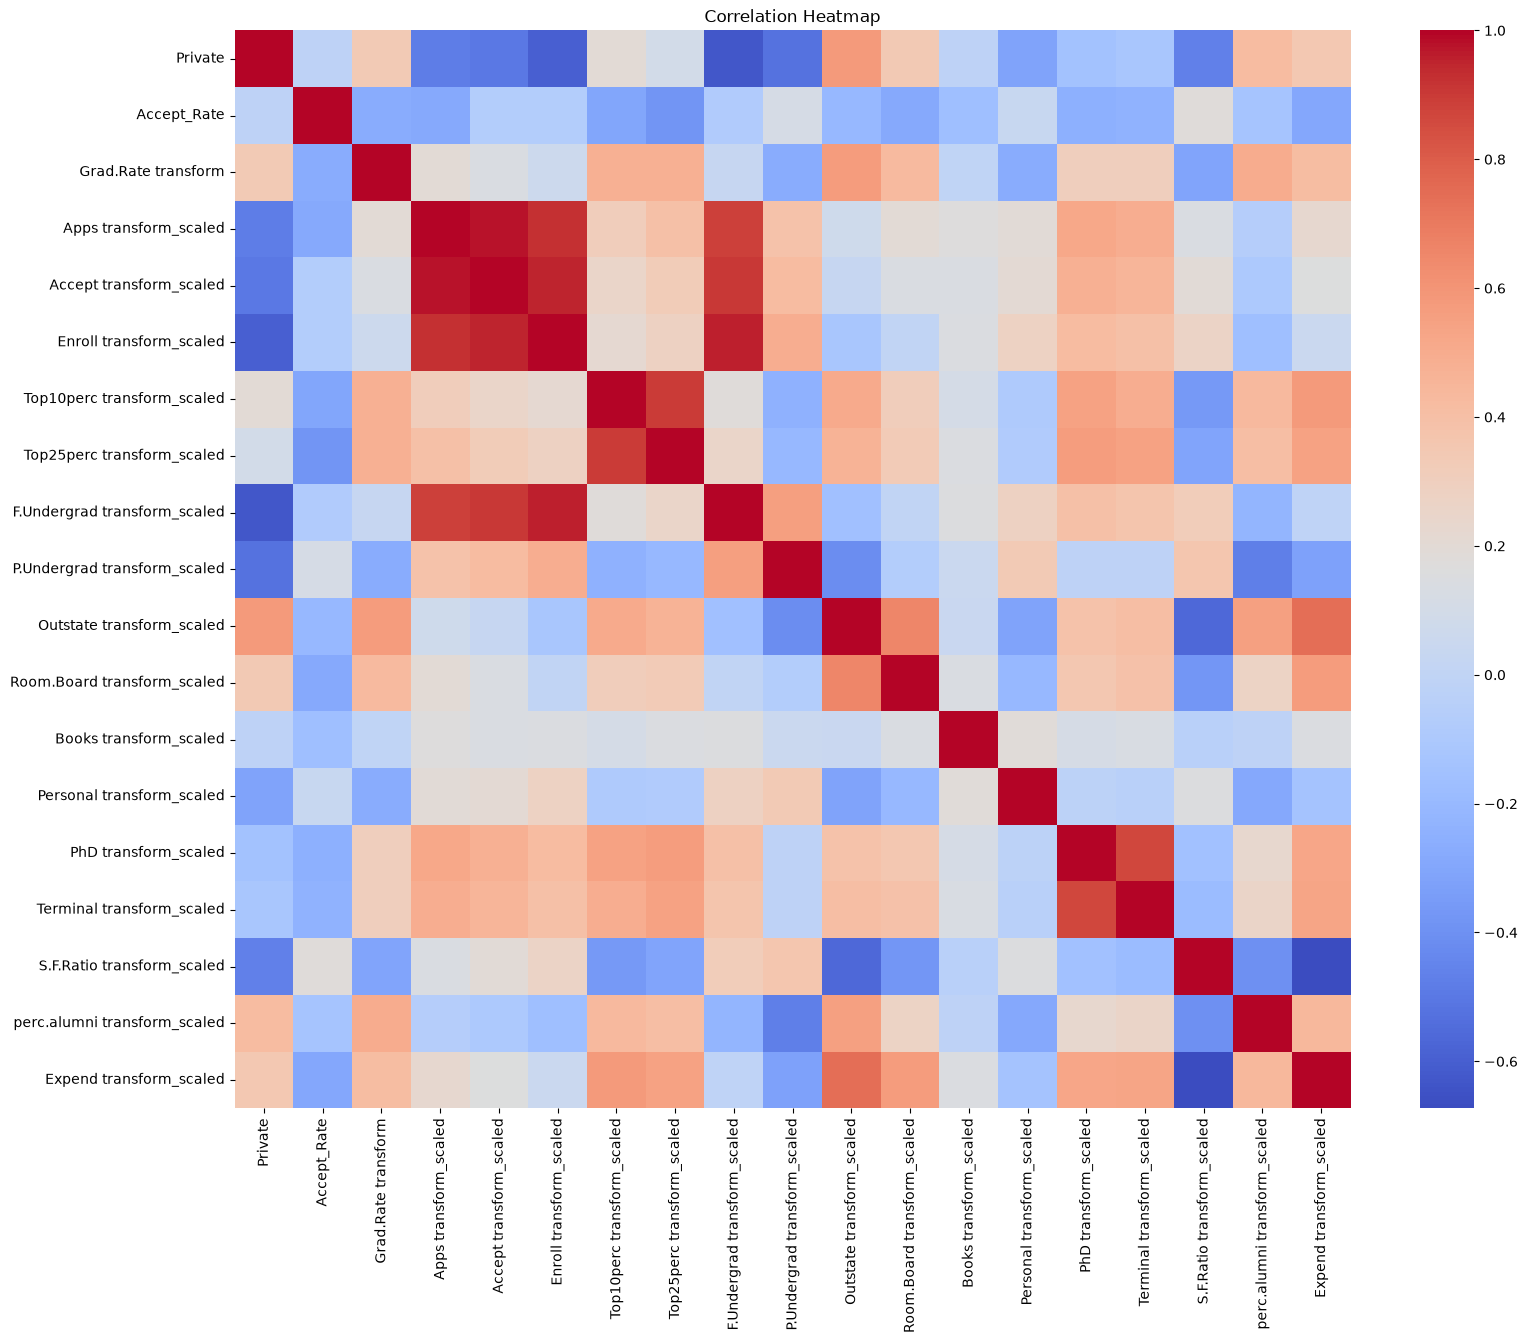

Grad.Rate transform             1.000000
Outstate transform_scaled       0.569352
perc.alumni transform_scaled    0.498713
Top10perc transform_scaled      0.481162
Top25perc transform_scaled      0.477281
Room.Board transform_scaled     0.424942
Expend transform_scaled         0.415444
Private                         0.336162
PhD transform_scaled            0.305822
Terminal transform_scaled       0.301981
Apps transform_scaled           0.200012
Accept transform_scaled         0.143551
Enroll transform_scaled         0.060103
F.Undergrad transform_scaled    0.032337
Books transform_scaled         -0.005642
Accept_Rate                    -0.269169
Personal transform_scaled      -0.269575
P.Undergrad transform_scaled   -0.273582
S.F.Ratio transform_scaled     -0.309696
Name: Grad.Rate transform, dtype: float64

In [28]:
# Your code here 
numeric_df = Scaled_College.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

#Which features look most related to Grad.Rate? Outstate transform_scaled, perc.alumni transform_scaled, and Top10perc transform_scaled
corr["Grad.Rate transform"].sort_values(ascending=False)




In [29]:
#Which features look most related to Grad.Rate? Outstate transform_scaled, perc.alumni transform_scaled, and Top10perc transform_scaled
corr["Grad.Rate transform"].sort_values(ascending=False)



Grad.Rate transform             1.000000
Outstate transform_scaled       0.569352
perc.alumni transform_scaled    0.498713
Top10perc transform_scaled      0.481162
Top25perc transform_scaled      0.477281
Room.Board transform_scaled     0.424942
Expend transform_scaled         0.415444
Private                         0.336162
PhD transform_scaled            0.305822
Terminal transform_scaled       0.301981
Apps transform_scaled           0.200012
Accept transform_scaled         0.143551
Enroll transform_scaled         0.060103
F.Undergrad transform_scaled    0.032337
Books transform_scaled         -0.005642
Accept_Rate                    -0.269169
Personal transform_scaled      -0.269575
P.Undergrad transform_scaled   -0.273582
S.F.Ratio transform_scaled     -0.309696
Name: Grad.Rate transform, dtype: float64

In [30]:
Scaled_College = Scaled_College.drop(columns=['Apps transform_scaled', 'Accept transform_scaled','Top25perc transform_scaled', 'F.Undergrad transform_scaled', 'Terminal transform_scaled'])

In [31]:
Scaled_College.columns

Index(['Private', 'Outstate_Tier', 'Accept_Rate', 'Grad.Rate transform',
       'Enroll transform_scaled', 'Top10perc transform_scaled',
       'P.Undergrad transform_scaled', 'Outstate transform_scaled',
       'Room.Board transform_scaled', 'Books transform_scaled',
       'Personal transform_scaled', 'PhD transform_scaled',
       'S.F.Ratio transform_scaled', 'perc.alumni transform_scaled',
       'Expend transform_scaled'],
      dtype='str')

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [32]:
College

# Your code here 
#Accept formula because transfomr methods is a same 
College ['Accept_Rate'] = College['Accept'] /College['Apps']
College["Outstate_Tier"] = pd.cut(
    College["Outstate"],
    bins=3,
    labels=["Low", "Medium", "High"]
)
College["Outstate_Tier"] = (
    College["Outstate_Tier"]
    .map({
        "Low": 0,
        "Medium": 1,
        "High": 2
    })
)
College["Private"] = (
    College["Private"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

College = College.dropna(subset=["PhD"])
Scaled_College = Scaled_College.dropna(subset=["PhD transform_scaled"])
College

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Accept_Rate,Outstate_Tier
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,...,450,2200,0.70,78,18.1,12,7041,0.60,0.742169,0
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,...,750,1500,0.29,30,12.2,16,10527,0.56,0.880146,1
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,...,400,1165,0.53,66,12.9,30,8735,0.54,0.768207,1
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,...,450,875,0.92,97,7.7,37,19016,0.59,0.836930,1
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,...,800,1500,0.76,72,11.9,2,10922,0.15,0.756477,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,0,2197,1515,543,4,26,3089,2029,6797,...,500,1200,0.60,60,21.0,14,4469,0.40,0.689577,0
773,Xavier University,1,1959,1805,695,24,47,2849,1107,11520,...,600,1250,0.73,75,13.3,31,9189,0.83,0.921388,1
774,Xavier University of Louisiana,1,2097,1915,695,34,61,2793,166,6900,...,617,781,0.67,75,14.4,20,8323,0.49,0.913209,0
775,Yale University,1,10705,2453,1317,95,99,5217,83,19840,...,630,2115,0.96,96,5.8,49,40386,0.99,0.229145,2


In [33]:
College.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate', 'Accept_Rate', 'Outstate_Tier'],
      dtype='str')

In [34]:
College.isnull().sum()

Unnamed: 0       0
Private          0
Apps             0
Accept           0
Enroll           0
Top10perc        0
Top25perc        0
F.Undergrad      0
P.Undergrad      0
Outstate         0
Room.Board       0
Books            0
Personal         0
PhD              0
Terminal         0
S.F.Ratio        0
perc.alumni      0
Expend           0
Grad.Rate        0
Accept_Rate      0
Outstate_Tier    0
dtype: int64

In [35]:
Scaled_College.isnull().sum()

Private                         0
Outstate_Tier                   0
Accept_Rate                     0
Grad.Rate transform             0
Enroll transform_scaled         0
Top10perc transform_scaled      0
P.Undergrad transform_scaled    0
Outstate transform_scaled       0
Room.Board transform_scaled     0
Books transform_scaled          0
Personal transform_scaled       0
PhD transform_scaled            0
S.F.Ratio transform_scaled      0
perc.alumni transform_scaled    0
Expend transform_scaled         0
dtype: int64

In [36]:
# Your code here
College = College.drop(columns=['Apps', 'Accept','Top25perc', 'F.Undergrad', 'Terminal'])

X_untransform = College.drop(columns=['Grad.Rate', 'Unnamed: 0'])
y_untransform = College['Grad.Rate']

X_train_untransform, X_test_untransform, y_train_untransform, y_test_untransform = train_test_split(X_untransform,y_untransform,test_size=0.2, random_state=10)

X_transform = Scaled_College.drop(columns=['Grad.Rate transform'])
y_transform = Scaled_College['Grad.Rate transform']

X_train_transform, X_test_transform, y_train_transform, y_test_transform = train_test_split(X_transform,y_transform,test_size=0.2, random_state=10)


#### 15. Fit a linear regression using the raw predictors


In [37]:
# Your code here 
# Create and fit the model
raw_model = LinearRegression()

raw_model.fit(
    X_train_untransform,
    y_train_untransform
)

# Make predictions
y_pred_untransform = raw_model.predict(X_test_untransform)

# Evaluate the model
raw_mae = mean_absolute_error(
    y_test_untransform,
    y_pred_untransform
)

raw_rmse = np.sqrt(
    mean_squared_error(
        y_test_untransform,
        y_pred_untransform
    )
)

raw_r2 = r2_score(
    y_test_untransform,
    y_pred_untransform
)

print("Raw predictors:")
print("MAE:", raw_mae)
print("RMSE:", raw_rmse)
print("R²:", raw_r2)

Raw predictors:
MAE: 0.09261850873042848
RMSE: 0.12032811837789277
R²: 0.4293768021623845


#### 16. Fit the same model using the log-transformed predictors

In [38]:
# Your code here 

# Create and fit the model
raw_model = LinearRegression()

raw_model.fit(
    X_train_transform,
    y_train_transform
)

# Make predictions
y_pred_transform = raw_model.predict(X_test_transform)

# Evaluate the model
raw_mae = mean_absolute_error(
    y_test_transform,
    y_pred_transform
)

raw_rmse = np.sqrt(
    mean_squared_error(
        y_test_transform,
        y_pred_transform
    )
)

raw_r2 = r2_score(
    y_test_transform,
    y_pred_transform
)

print("Raw predictors:")
print("MAE:", raw_mae)
print("RMSE:", raw_rmse)
print("R²:", raw_r2)

Raw predictors:
MAE: 0.0907369204631009
RMSE: 0.11781624387309242
R²: 0.4529518951718632


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

The transformed model performed slightly better than the raw model. The R² score increased from 0.4294 to 0.4530, indicating that the transformed predictors explain a slightly larger proportion of the variance in the graduation rate. In addition, both MAE (0.0926 → 0.0907) and RMSE (0.1203 → 0.1178) decreased, showing a small improvement in prediction accuracy. Therefore, using the transformed predictors produced a modest but consistent improvement over the model using the raw predictors.

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [39]:
# Your code here 
Scaled_College.to_csv('data/Clean_College_Dataset.csv', index = False)
